In [97]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import optuna
import ta
from src import pre_process_data_multidim,prepare_data, prepare_data_up_down, prepare_data_multidim, read_yfinance_crypto_data, full_evaluation_flow, optimize_hyperparameters, split_data_set, model_builder, model_builder_binary_class

In [106]:
# Fetch Ripple price data
df = read_yfinance_crypto_data("EURUSD=x", "max", "1d")

In [107]:
#Calculate TAs
rsi = ta.momentum.RSIIndicator(close=df["Close"]).rsi()
bb = ta.volatility.BollingerBands(close=df["Close"], window=5, window_dev=2)
df["rsi"] = rsi
# Add Bollinger Bands to DataFrame
df["bb_m"] = bb.bollinger_mavg() # Middle Band (SMA)
df["bb_u"] = bb.bollinger_hband() # Upper Band
df["bb_l"] = bb.bollinger_lband() # Lower Band

df.bfill(inplace=True)

In [108]:

scaler = MinMaxScaler()

[
    [train_date_series, train_data, normalized_data],
    [test_date_series, testData, normalized_test_data]
] = pre_process_data_multidim(
    [
        df["Close"],
        df["Volume"],
        df["rsi"],
        df["bb_m"], # Middle Band (SMA)
        df["bb_u"], # Upper Band
        df["bb_l"]
    ], scaler)

print(f"Train Data: {train_data.shape}\nTest Data: {testData.shape}")

test_target = testData
print(f"Train Target: {train_data.shape}\nTest Data: {test_target.shape}")

[array([[1.19650137],
       [1.20889747],
       [1.21229756],
       ...,
       [1.03972793],
       [1.0247792 ],
       [1.03788269]]), array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]]), array([[85.81675495],
       [85.81675495],
       [85.81675495],
       ...,
       [49.91404542],
       [36.37123424],
       [49.34522951]]), array([[1.20889707],
       [1.20889707],
       [1.20889707],
       ...,
       [1.04328454],
       [1.03888865],
       [1.0375639 ]]), array([[1.22337061],
       [1.22337061],
       [1.22337061],
       ...,
       [1.04792639],
       [1.05333003],
       [1.05087163]]), array([[1.19442352],
       [1.19442352],
       [1.19442352],
       ...,
       [1.03864268],
       [1.02444726],
       [1.02425616]])]
(5497, 6)
(5497, 6)
Cutoff:  1649
Cutoff:  1649
Cutoff:  1649
Train Data: (3848, 6)
Test Data: (1649, 6)
Train Target: (3848, 6)
Test Data: (1649, 6)


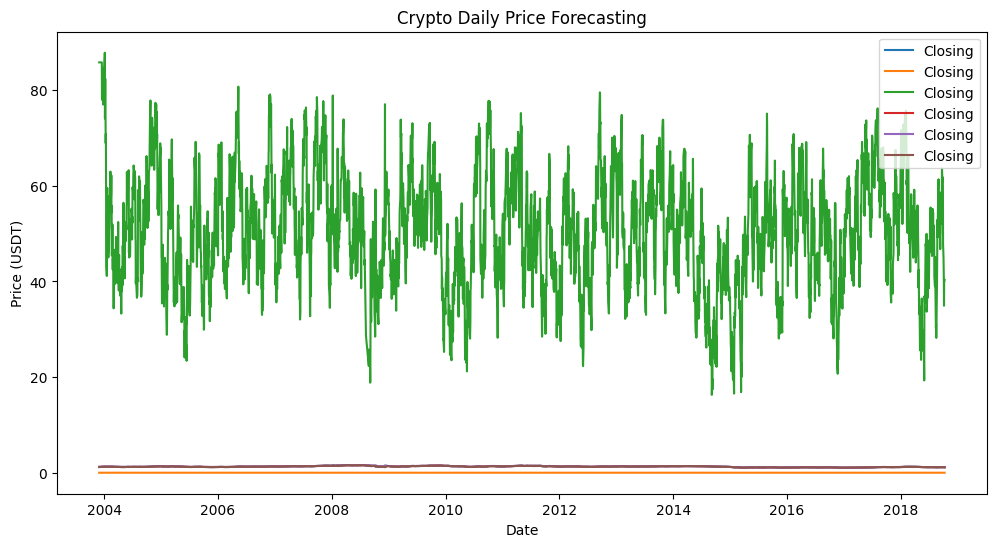

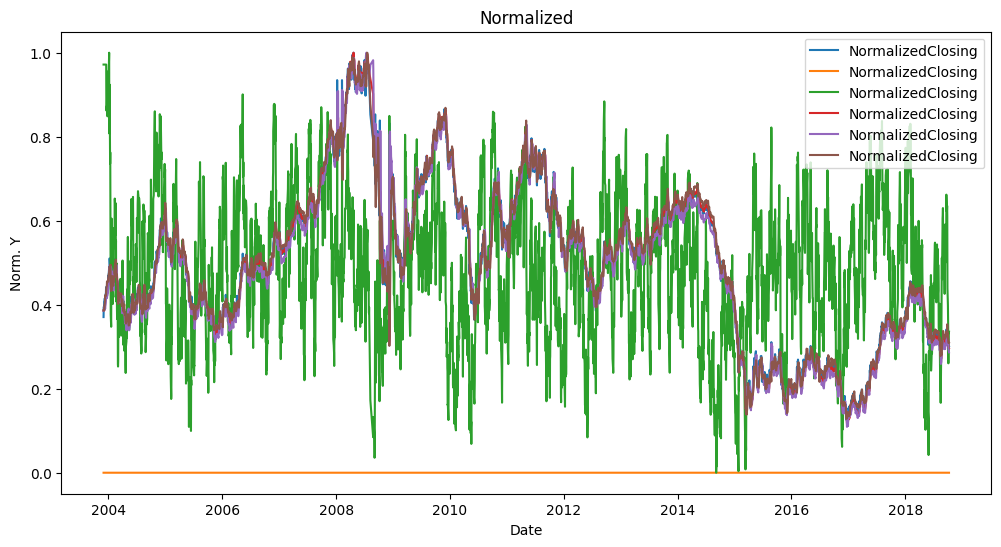

In [109]:
# Plot train data
plt.figure(figsize=(12, 6))
plt.plot(train_date_series, train_data[:], label='Closing')
plt.title('Crypto Daily Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(train_date_series, normalized_data, label='NormalizedClosing')
plt.title('Normalized')
plt.xlabel('Date')
plt.ylabel('Norm. Y')
plt.legend()
plt.show()

In [110]:
# Prepare data for each EWT component
seq_len = 90
print(normalized_data.shape)
X, y, train_data, train_date_series = prepare_data_multidim(
    normalized_data,
    train_data,
    train_date_series,
    seq_len
)

print(y.shape, X.shape, train_date_series.shape, train_data.shape)

(3848, 6)
(3848, 6) (3848, 6)
(3758, 1) (3758, 90, 6) (3758,) (3758, 6)


In [111]:
y


array([[1.20130217],
       [1.21310639],
       [1.21660423],
       ...,
       [1.14763129],
       [1.15180838],
       [1.15225959]])

In [112]:
# The training data is separated in a train set to train each opt iteration and a validation one
# to validate each iteration.

x_train, x_val = split_data_set(X, 0.3)
y_train, y_val = split_data_set(y, 0.3)

print(x_train.shape, x_val.shape)

Cutoff:  1127
Cutoff:  1127
(2631, 90, 6) (1127, 90, 6)


In [ ]:
model = model_builder(
    246,
    0.22247614754696465,
    55,
    0.0007413033489541297,
    x_train[0].shape
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=16,
    epochs=136,
    verbose=1
)

Epoch 1/136
165/165 ━━━━━━━━━━━━━━━━━━━━ 55s 320ms/step - loss: 0.1221 - val_loss: 0.0074
Epoch 2/136
165/165 ━━━━━━━━━━━━━━━━━━━━ 58s 352ms/step - loss: 9.4685e-04 - val_loss: 0.0055
Epoch 3/136


In [ ]:
full_evaluation_flow(
    model,
    prepare_data_multidim,
    normalized_test_data,
    testData,
    test_date_series,
    seq_len,
    "eurusd-multi-feature-tendency"
)

In [ ]:
!mkdir -p saved_models
model.save("saved_models/eurusd-multi-feat-tendency-p90-2L.keras")